<a href="https://colab.research.google.com/github/Dewss15/EV-charging-station-analysis/blob/main/data_prep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. DOWNLOAD AND LOAD THE DATA
# ---------------------------------------------------------
print("Downloading dataset from Kaggle...")
path = kagglehub.dataset_download("jayjoshi37/ev-charging-station-usage-and-grid-load-analysis")

# Find the CSV file inside the hidden downloaded folder
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_file)

# Load the data into a Pandas DataFrame
df = pd.read_csv(full_file_path)

# ---------------------------------------------------------
# 2. DATA UNDERSTANDING, STATISTICS & DUPLICATES
# ---------------------------------------------------------
print("\n--- A. Dataset Info ---")
print(df.info())

print("\n--- B. Missing Values Check ---")
print(df.isnull().sum())

print("\n--- C. Duplicate Check ---")
duplicate_count = df.duplicated().sum()
print(f"Total duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates()
    print("Action: Duplicates have been removed.")
else:
    print("Action: No duplicates to remove.")

print("\n--- D. Basic Statistics (Pre-Scaling) ---")
print(df.describe().round(2))

# ---------------------------------------------------------
# 3. FEATURE ENGINEERING
# ---------------------------------------------------------
# Convert date_time string to actual datetime objects
df['date_time'] = pd.to_datetime(df['date_time'])

# Extract useful time-based numerical features
df['hour_of_day'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek # Monday=0, Sunday=6

# Drop the original date_time column as models cannot read it
df = df.drop(columns=['date_time'])

# ---------------------------------------------------------
# 4. ENCODING CATEGORICAL VARIABLES
# ---------------------------------------------------------
# One-Hot Encoding (Guarantees binary 0/1 integer columns instead of True/False)
df = pd.get_dummies(df, columns=['station_type', 'city_zone'], drop_first=True, dtype=int)

# Explicit Ordinal Mapping for the Target Variable (Viva-proof!)
risk_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df['peak_load_risk_encoded'] = df['peak_load_risk'].map(risk_mapping)

print("\n--- Target Variable Mapping (Ordinal) ---")
for text_label, num_label in risk_mapping.items():
    print(f"{text_label} -> {num_label}")

# Drop the original text target column
df = df.drop(columns=['peak_load_risk'])

# ---------------------------------------------------------
# 5. SCALING NUMERICAL VARIABLES
# ---------------------------------------------------------
scaler = StandardScaler()
num_cols = ['energy_dispensed_kwh', 'avg_charging_duration_minutes',
            'grid_load_mw', 'vehicles_charged', 'renewable_energy_used_percent']

# Transform continuous variables so they have a mean of 0 and std deviation of 1
df[num_cols] = scaler.fit_transform(df[num_cols])

# ---------------------------------------------------------
# 6. FINAL OUTPUTS FOR REPORT
# ---------------------------------------------------------
print("\n--- Preprocessing Complete! ---")
print(f"\nDataset Shape After Preprocessing: {df.shape}")

print("\n--- Final Feature Names ---")
print(df.columns.tolist())

print("\nFirst 5 Rows of Cleaned Data:")
print(df.head())

100%|██████████| 54.2k/54.2k [00:00<00:00, 46.9MB/s]

Extracting files...

--- A. Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   record_id                      2800 non-null   int64  
 1   date_time                      2800 non-null   object 
 2   city_zone                      2800 non-null   object 
 3   station_type                   2800 non-null   object 
 4   vehicles_charged               2800 non-null   int64  
 5   avg_charging_duration_minutes  2800 non-null   float64
 6   energy_dispensed_kwh           2800 non-null   float64
 7   grid_load_mw                   2800 non-null   float64
 8   renewable_energy_used_percent  2800 non-null   float64
 9   peak_load_risk                 2800 non-null   object 
dtypes: float64(4), int64(2), object(4)
memory usage: 218.9+ KB
None

--- B. Missing Values Check ---
record_id                 

       record_id  vehicles_charged  avg_charging_duration_minutes  \
count    2800.00           2800.00                        2800.00   
mean     1400.50             12.49                          67.39   
std       808.43              6.94                          30.53   
min         1.00              1.00                          15.00   
25%       700.75              7.00                          41.30   
50%      1400.50             12.00                          67.00   
75%      2100.25             19.00                          94.00   
max      2800.00             24.00                         119.90   

       energy_dispensed_kwh  grid_load_mw  renewable_energy_used_percent  
count               2800.00       2800.00                        2800.00  
mean                 178.83        276.36                          44.93  
std                   98.98        130.04                          22.95  
min                   10.02         50.01                           5.00  
25%

--- 1. Correlation Matrix (Similarity) ---


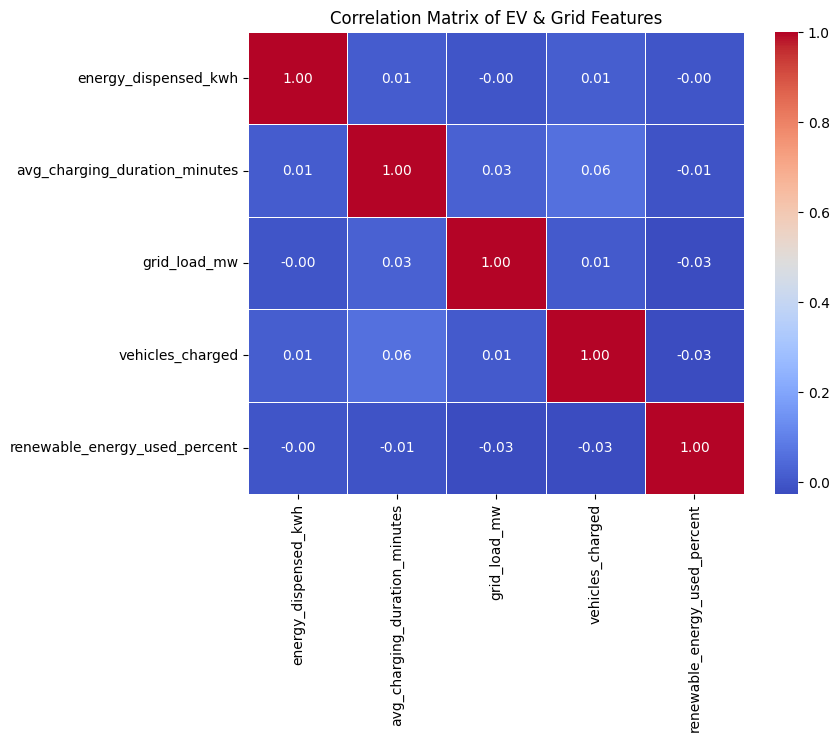


--- 2. Euclidean Distance (Dissimilarity between City Zones) ---


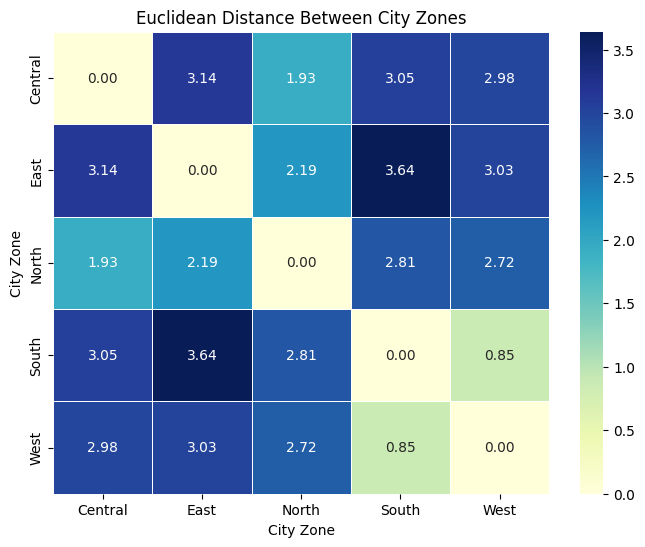

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ---------------------------------------------------------
# 1. MEASURE OF SIMILARITY: Correlation Matrix
# ---------------------------------------------------------
print("--- 1. Correlation Matrix (Similarity) ---")

# Calculate Pearson correlation on the already-scaled numerical columns from Step 5
corr_matrix = df[num_cols].corr()

# Plotting the Similarity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of EV & Grid Features')
plt.show()

# ---------------------------------------------------------
# 2. MEASURE OF DISSIMILARITY: Euclidean Distance
# ---------------------------------------------------------
print("\n--- 2. Euclidean Distance (Dissimilarity between City Zones) ---")

# Load the raw data temporarily to group by the original text names
df_raw = pd.read_csv(full_file_path)

# Group by 'city_zone' and calculate the mean for our key metrics
zone_profiles = df_raw.groupby('city_zone')[
    ['energy_dispensed_kwh', 'grid_load_mw', 'vehicles_charged']
].mean()

# rigorously scale the grouped profiles before calculating distance
scaler_dist = StandardScaler()
zone_scaled = pd.DataFrame(
    scaler_dist.fit_transform(zone_profiles),
    index=zone_profiles.index,
    columns=zone_profiles.columns
)

# Calculate Euclidean distance on the standardized profiles
dist_matrix = euclidean_distances(zone_scaled)

# Convert the resulting matrix into a Pandas DataFrame using the zone names as labels
dist_df = pd.DataFrame(dist_matrix, index=zone_profiles.index, columns=zone_profiles.index)

# Plotting the Dissimilarity Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(dist_df, annot=True, cmap='YlGnBu', linewidths=0.5, fmt='.2f')
plt.title("Euclidean Distance Between City Zones")
plt.xlabel("City Zone")
plt.ylabel("City Zone")
plt.show()

--- STEP 7: Training Classification Model ---
Balancing classes with SMOTE...
Fixed Model Accuracy: 42.86%

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.61      0.57       281
           1       0.30      0.30      0.30       166
           2       0.27      0.17      0.21       113

    accuracy                           0.43       560
   macro avg       0.37      0.36      0.36       560
weighted avg       0.41      0.43      0.42       560


--- STEP 8: Running K-Means Clustering ---
Saved file: kmeans_labels.csv

--- STEP 9: Running Isolation Forest ---
Saved file: flagged_outliers.csv (Detected 84 anomalies)

--- STEP 10: Generating 1x3 Dashboard ---


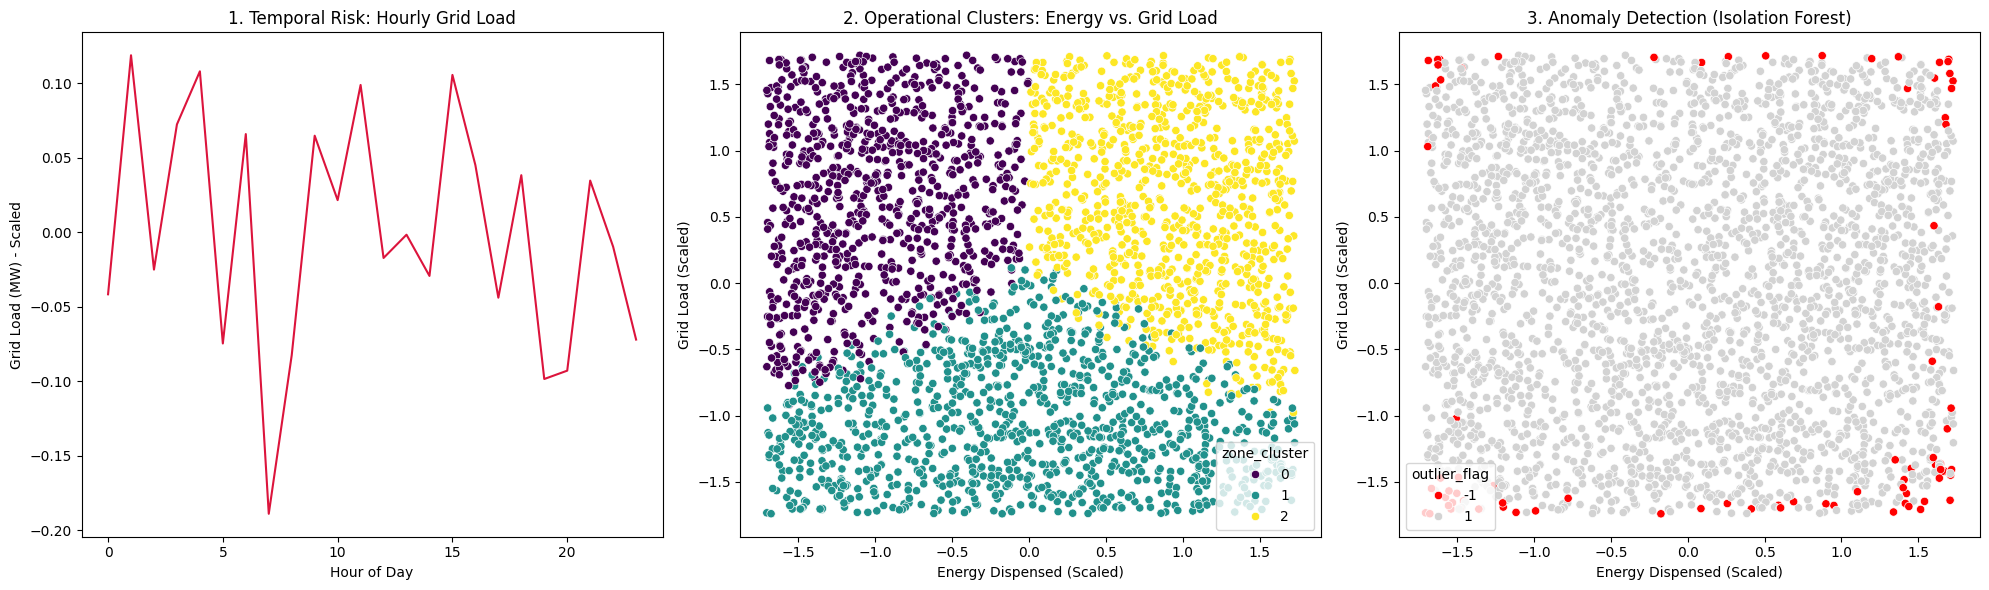

Saved file: final_dashboard.png


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# STEP 7: CLASSIFICATION (WITH SMOTE FIX)
# ==========================================
print("--- STEP 7: Training Classification Model ---")

# Define inputs (X) and target (y)
# We drop the target variable and any non-predictive columns like record_id if it exists
cols_to_drop = ['peak_load_risk_encoded']
if 'record_id' in df.columns:
    cols_to_drop.append('record_id')

X = df.drop(columns=cols_to_drop)
y = df['peak_load_risk_encoded']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to fix the class imbalance Dewpearl found
print("Balancing classes with SMOTE...")
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# Train the Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_resampled, y_train_resampled)
y_pred = rf.predict(X_test)

new_accuracy = accuracy_score(y_test, y_pred)
print(f"Fixed Model Accuracy: {new_accuracy * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================
# STEP 8: K-MEANS CLUSTERING
# ==========================================
print("\n--- STEP 8: Running K-Means Clustering ---")
# Using the continuous numerical columns Dewpearl already scaled
X_cluster = df[['energy_dispensed_kwh', 'grid_load_mw', 'avg_charging_duration_minutes']]

# Fit K-Means (Grouping into 3 usage profiles)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['zone_cluster'] = kmeans.fit_predict(X_cluster)

# Save Deliverable
# Extracting zone columns and cluster labels for the CSV
zone_cols = [col for col in df.columns if 'city_zone' in col]
df[zone_cols + ['zone_cluster']].to_csv('kmeans_labels.csv', index=False)
print("Saved file: kmeans_labels.csv")

# ==========================================
# STEP 9: ISOLATION FOREST (OUTLIERS)
# ==========================================
print("\n--- STEP 9: Running Isolation Forest ---")
# Flagging the top 3% most extreme, anomalous charging events
iso_forest = IsolationForest(contamination=0.03, random_state=42)
df['outlier_flag'] = iso_forest.fit_predict(X_cluster)

# Filter out the anomalies (-1 means outlier)
outliers = df[df['outlier_flag'] == -1]

# Save Deliverable
outliers.to_csv('flagged_outliers.csv', index=False)
print(f"Saved file: flagged_outliers.csv (Detected {len(outliers)} anomalies)")

# ==========================================
# STEP 10: 1x3 FINAL DASHBOARD
# ==========================================
print("\n--- STEP 10: Generating 1x3 Dashboard ---")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Temporal Risk (Hourly Grid Load)
sns.lineplot(data=df, x='hour_of_day', y='grid_load_mw', ax=axes[0], color='crimson', errorbar=None)
axes[0].set_title('1. Temporal Risk: Hourly Grid Load')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Grid Load (MW) - Scaled')

# Panel 2: K-Means Clusters
sns.scatterplot(data=df, x='energy_dispensed_kwh', y='grid_load_mw', hue='zone_cluster', palette='viridis', ax=axes[1])
axes[1].set_title('2. Operational Clusters: Energy vs. Grid Load')
axes[1].set_xlabel('Energy Dispensed (Scaled)')
axes[1].set_ylabel('Grid Load (Scaled)')

# Panel 3: Anomalies Overlay
sns.scatterplot(data=df, x='energy_dispensed_kwh', y='grid_load_mw', hue='outlier_flag', palette={1: 'lightgrey', -1: 'red'}, ax=axes[2])
axes[2].set_title('3. Anomaly Detection (Isolation Forest)')
axes[2].set_xlabel('Energy Dispensed (Scaled)')
axes[2].set_ylabel('Grid Load (Scaled)')

plt.tight_layout()
plt.savefig('final_dashboard.png', dpi=300)
plt.show()
print("Saved file: final_dashboard.png")